# Decision Tree

In [22]:
# 실습 1 사용한 라이브러리

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
# 실습 1-1 아이리스 데이터 셋 활용한 Decision tree

iris = load_iris()
x_train, x_test, y_train, y_test = train_test_split(iris.data,
                                                    iris.target,
                                                    stratify=iris.target)

iris_dt = DecisionTreeClassifier()
iris_dt.fit(x_train, y_train)
pred = iris_dt.predict(x_test)

print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

print(iris_dt.feature_importances_)    # 데이터가 가지고 있는 속성 중 활용한 속성

0.9736842105263158
[[13  0  0]
 [ 0 13  0]
 [ 0  1 11]]
[0.         0.01785857 0.04643227 0.93570916]


In [3]:
# 실습 1-1 부연설명 사용된 속성

print(iris.DESCR)

# 0번 속성 sepal length in cm /꽃받침 길이
# 1번 속성 sepal width in cm  /꽃받침 너비
# 2번 속성 petal length in cm /꽃잎 길이
# 3번 속성 petal width in cm  /꽃잎 너비

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

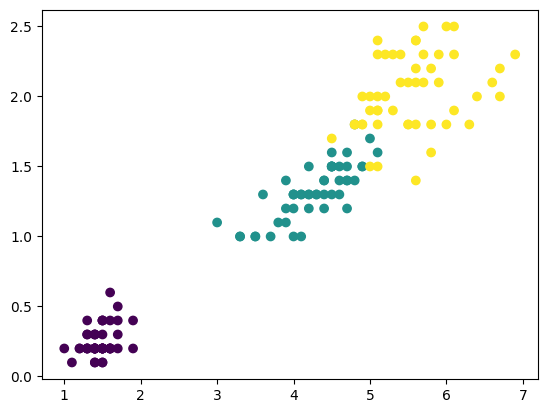

In [4]:
# 실습 1-2 그래프로 확인해보기
                                            # 색깔은 타겟 종류별로
plt.scatter(iris.data[:, 2], iris.data[:,3], c=iris.target)
plt.show()


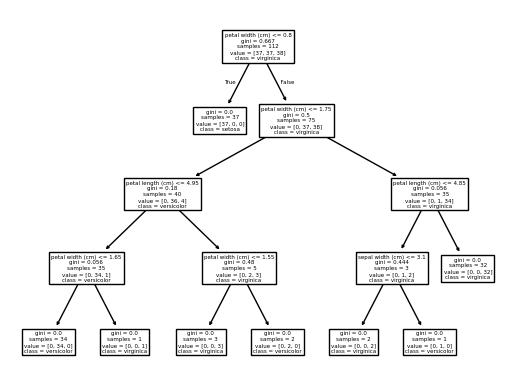

In [5]:
# 실습 1-3 Decision Tree 확인

plot_tree(iris_dt,
          feature_names = iris.feature_names,  # 질문(노드)의 이름(너비 등)
          class_names = iris.target_names)     # 정답의 이름(세토사 등)
plt.show()

0.6578947368421053
0.9736842105263158
1.0
0.9473684210526315
0.9736842105263158
0.9736842105263158
0.9736842105263158
0.9736842105263158
0.9736842105263158
0.9473684210526315


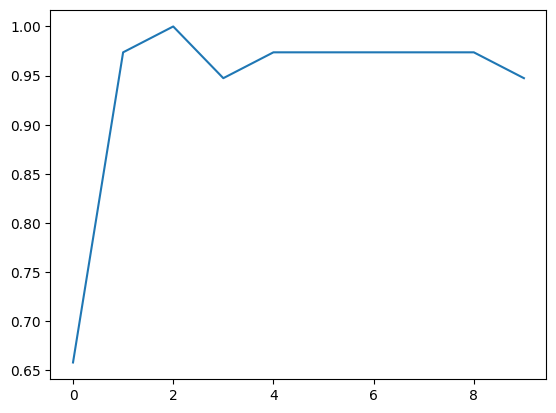

In [6]:
# 실습 2 max_depth 적용

acc=[]
for dep in range(1,11) :

  iris_dt = DecisionTreeClassifier(max_depth = dep)
  iris_dt.fit(x_train, y_train)
  pred = iris_dt.predict(x_test)
  acc.append(accuracy_score(y_test, pred))
  print(accuracy_score(y_test, pred))

plt.plot(acc)
plt.show()

In [7]:
# 실습 3 Breast Cancer 데이터 학습

from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()

x_train, x_test, y_train, y_test = train_test_split(bc.data,
                                                    bc.target,
                                                    stratify=bc.target)

print(bc.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

0.9090909090909091
0.951048951048951
0.9440559440559441
0.958041958041958
0.972027972027972
0.9440559440559441
0.9440559440559441
0.9440559440559441
0.951048951048951
0.965034965034965


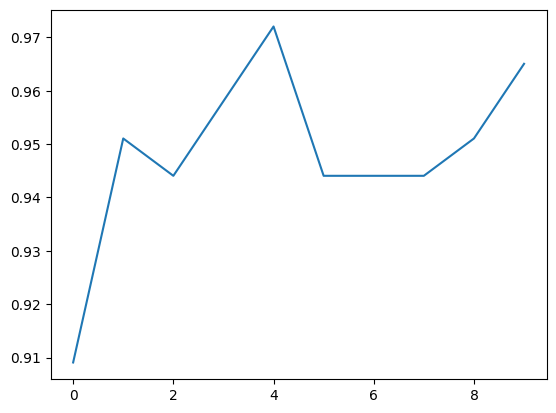

In [8]:
# 실습 3-2 최적의 max_depth 도출

acc=[]
for dep in range(1,11) :

  bc_dt = DecisionTreeClassifier(max_depth = dep)
  bc_dt.fit(x_train, y_train)
  pred = bc_dt.predict(x_test)
  acc.append(accuracy_score(y_test, pred))
  print(accuracy_score(y_test, pred))

plt.plot(acc)
plt.show()

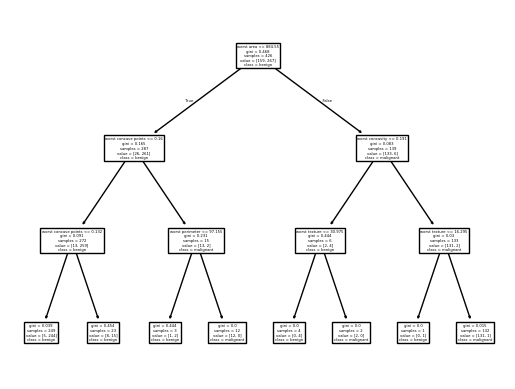

In [10]:
# 실습 3-3 결정트리 그리기

bc_dt = DecisionTreeClassifier(max_depth = 3)
bc_dt.fit(x_train, y_train)
pred = bc_dt.predict(x_test)

plot_tree(bc_dt,
          feature_names = bc.feature_names,
          class_names = bc.target_names)
plt.show()

In [ ]:
# 실습 4 파이프라인 적용

split = StratifiedShuffleSplit(10)
pip = Pipeline([('preprocess', StandardScaler()),
                ('classifier', KNeighborsClassifier())
                ])

g_pram = [
    {"preprocess":[StandardScaler()],           # 전처리
     "classifier":[KNeighborsClassifier()],     # 모델
     "classifier__n_neighbors": range(1,30,2)}, # 모델 옵션 설정   // 왜 29까지 홀수인가? = 짝수는 동점이 나올 수 있음 // 전체 학습 데이터 개수의 제곱근으로 적용

    {"preprocess":[None],                       # 전처리 필요없음
     "classifier":[GaussianNB()]},              # 모델

    {"preprocess":[None],                       # 전처리 필요없음
     "classifier" :[DecisionTreeClassifier()],  # 모델
     "classifier__max_depth": range(1,20),      # 모델 옵션 설정  // 왜 20까지 인가? = log_2(N) 으로 적정 max depth 산출
     "classifier__criterion":['gini', 'entropy']# 모델 옵션 설정  // 불순도 측정 기준(지니, 엔트로피) : 데이터마다 유리한 것이 달라서 둘다 적용해서 도출하는 것이 나음
     }
]

grid_m = GridSearchCV(pip,                      # 구조를 반영
                      param_grid = g_pram,      # grid 설정 적용
                      cv=split,                 # StratifiedKFold 방식 적용
                      return_train_score=True,  # 훈련점수도 기록
                      verbose=3)                # 과정의 디테일 출력

grid_m.fit(bc.data, bc.target)
print(grid_m.best_params_, grid_m.best_score_)

Fitting 10 folds for each of 54 candidates, totalling 540 fits
[CV 1/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.947) total time=   0.0s
[CV 2/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.947) total time=   0.0s
[CV 3/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.965) total time=   0.0s
[CV 4/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=1.000) total time=   0.0s
[CV 5/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.965) total time=   0.0s
[CV 6/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.982) total time=   

In [ ]:
# 실습5 랜덤 포레스트

bc_rf = RandomForestClassifier()
bc_rf.fit(x_train, y_train)
pred = bc_rf.predict(x_test)
print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

0.951048951048951
[[48  5]
 [ 2 88]]


# redwine 실습

1. 데이터 읽기
2. 데이터를 이해하기 위한 EDA
3. 전처리 하기
4. KNN, NB, DT, RF 를 이용하여 각각 최적의 파라미터 찾기
5. 가장 좋은 성능을 내는 알고리즘과 최적의 파라미터와 Accuracy 찾기

## 1. 데이터 읽기

In [23]:

import os
import pandas as pd
import numpy as np
import seaborn as sns


os.chdir('/content/drive/MyDrive/Colab Notebooks/06 머신러닝/Day_03_file')
os.getcwd()
df = pd.read_csv('redwine_quality.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


## 2. 데이터 이해하기 위한 EDA

In [16]:
# 12개 속성, 1599개 데이터

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# 결측치 조회(없음)

# 동일하게 사용할 수 있는 코드
# df.isna().sum()
# df.info()
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
# 데이터 기술통계

print(df.describe())

       fixed acidity  volatile acidity  ...      alcohol      quality
count    1599.000000       1599.000000  ...  1599.000000  1599.000000
mean        8.319637          0.527821  ...    10.422983     5.636023
std         1.741096          0.179060  ...     1.065668     0.807569
min         4.600000          0.120000  ...     8.400000     3.000000
25%         7.100000          0.390000  ...     9.500000     5.000000
50%         7.900000          0.520000  ...    10.200000     6.000000
75%         9.200000          0.640000  ...    11.100000     6.000000
max        15.900000          1.580000  ...    14.900000     8.000000

[8 rows x 12 columns]


In [ ]:
# 등급 분포

df[['quality']].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


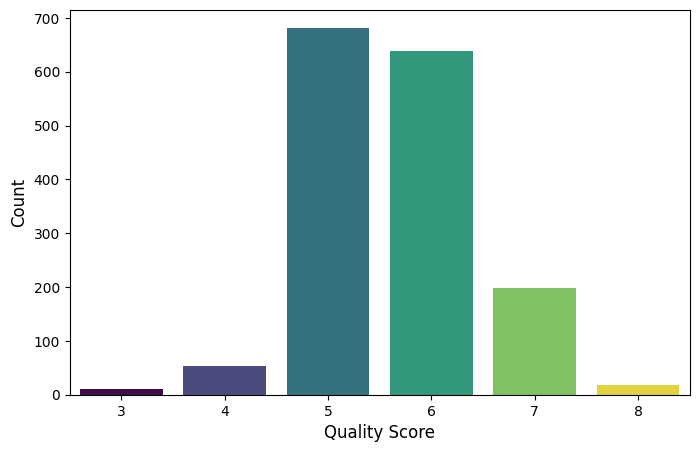

In [ ]:
# 등급 분포도

plt.figure(figsize=(8, 5))

# 속성별 몇 개 들어있는지 그래프로 확인

sns.countplot(x='quality',       # x축 등급,
              data=df,           # 등급을 어디에서 찾음? df에서
              hue='quality',     # 등급별로 색상 다르게
              palette='viridis', # 색상 패키지('Set3', 'plasma', 'coolwarm' 등 존재)
              legend=False)      # 범례 미표시
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)

'''
5,6등급 많음

'''

plt.show()

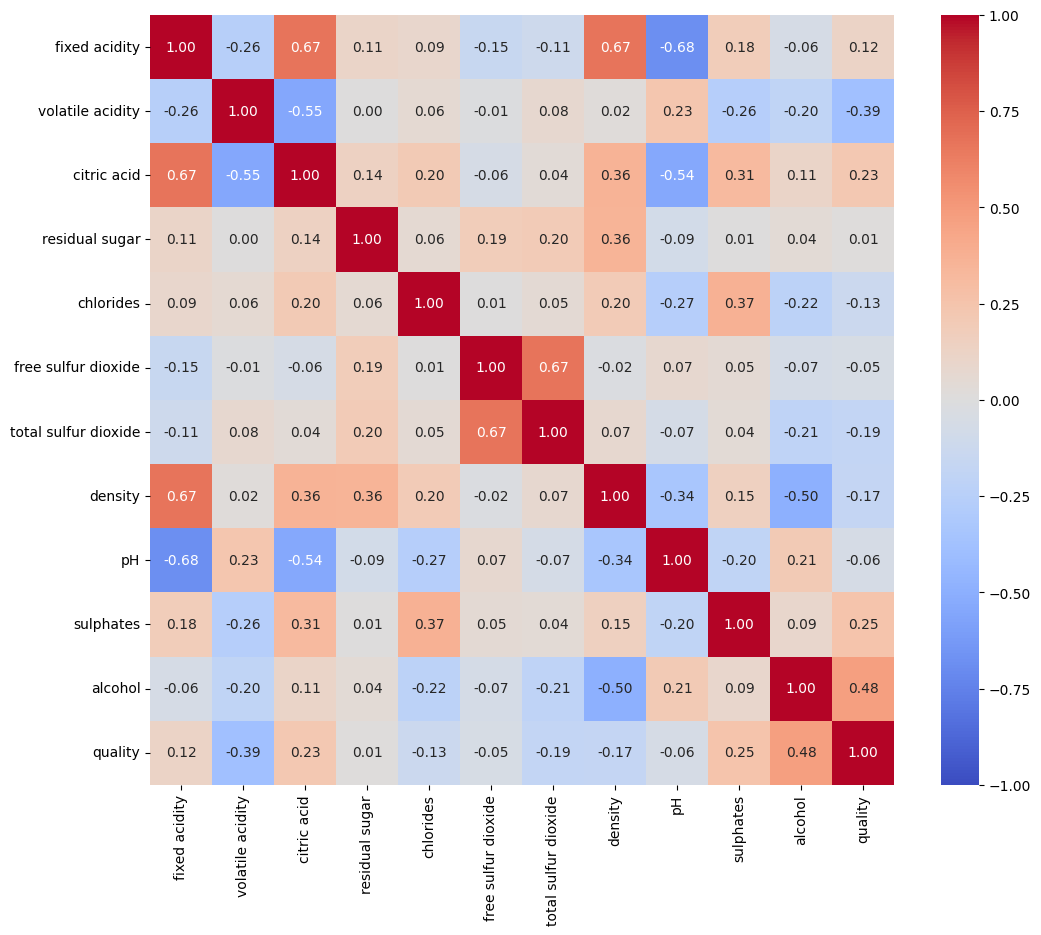

In [18]:
# 변수 간 상관관계 분석

# 어떤 성분이 와인 품질(quality)과 연관성이 높은지 확인.
# 히트맵에서 보통 alcohol(알코올)이나 volatile acidity(휘발성 산도)가 품질과 상관관계가 높게 나옵니다.

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()      # 상관계수 적용
sns.heatmap(corr_matrix,     # 사용 데이터
            annot=True,      # 숫자 표시
            fmt='.2f',       # 숫자 표기방식(소수점 둘째자리)
            vmin=-1,         # 숫자 최소치
            vmax=1,          # 숫자 최대치
            cmap='coolwarm'  # 색상 테마
            )
plt.show()

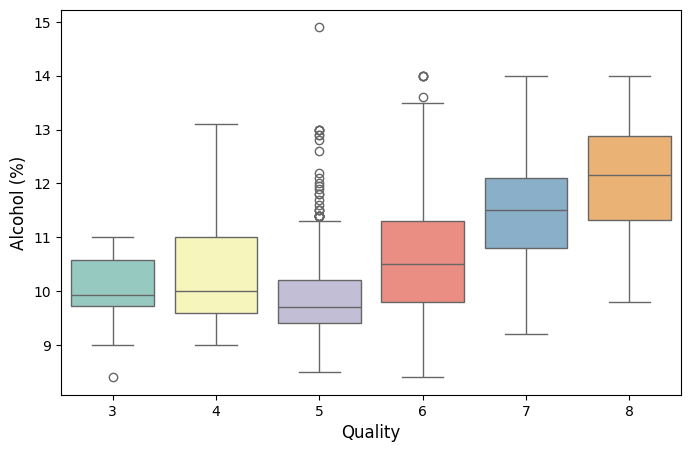

In [ ]:
# 주요 변수와 Quality의 관계 시각화 (Boxplot)

# 알코올 도수와 와인 품질의 관계를 박스플롯으로 확인.
plt.figure(figsize=(8, 5))
sns.boxplot(x='quality',
            y='alcohol',
            data=df,
            hue='quality',
            palette='Set3',
            legend=False)
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Alcohol (%)', fontsize=12)
plt.show()

## 3. 전처리

In [24]:
# 문제지(X)와 정답지(y) 분리하기

# 'quality' 열은 정답이므로 X에서 제외하고, y에만 담습니다.
x = df.drop('quality', axis=1)
y = df['quality']

# Train, Test 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,   # 8:2 비율
                                                    random_state=42, # random_state=42 : 결과를 고정하기 위한 시드값
                                                    stratify=y       # stratify=y : 원본 데이터의 등급(quality) 비율을 그대로 유지하면서 분할합니다.
                                                    )

# 데이터 스케일링 (표준화)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # fit과 transform 동시에 적용 가능
x_test_scaled = scaler.transform(x_test)

print(f"원본 데이터 크기: {df.shape}")
print(f"Train 데이터 크기: {x_train_scaled.shape}")
print(f"Test 데이터 크기: {x_test_scaled.shape}")

원본 데이터 크기: (1599, 12)
Train 데이터 크기: (1279, 11)
Test 데이터 크기: (320, 11)


## 4. KNN, NB, DT, RF 를 이용하여 각각 최적의 파라미터 찾기

(파이프라인 미적용 ver)

In [25]:
g_pram = [
    {"preprocess":[StandardScaler()],           # 전처리
     "classifier":[KNeighborsClassifier()],     # 모델
     "classifier__n_neighbors": range(1,30,2)}, # 모델 옵션 설정   // 왜 29까지 홀수인가? = 짝수는 동점이 나올 수 있음 // 전체 학습 데이터 개수의 제곱근으로 적용

    {"preprocess":[None],                       # 전처리 필요없음
     "classifier":[GaussianNB()]},              # 모델

    {"preprocess":[None],                       # 전처리 필요없음
     "classifier" :[DecisionTreeClassifier()],  # 모델
     "classifier__max_depth": range(1,20),      # 모델 옵션 설정  // 왜 20까지 인가? = log_2(N) 으로 적정 max depth 산출
     "classifier__criterion":['gini', 'entropy']# 모델 옵션 설정  // 불순도 측정 기준(지니, 엔트로피) : 데이터마다 유리한 것이 달라서 둘다 적용해서 도출하는 것이 나음
     }
]

In [ ]:
# 평가할 모델들과 탐색할 파라미터 딕셔너리로 묶기

models_and_params = {
    'KNN': (KNeighborsClassifier(),
           {'n_neighbors': range(1,100,2)}),              # 1600의 제곱근은 약 40

    'Naive Bayes': (GaussianNB(), {}),

    'Decision Tree': (DecisionTreeClassifier(),
                      {'max_depth': range(1,15),          # log2(1600) = 약 10
                       "criterion":['gini', 'entropy']}),

    'Random Forest': (RandomForestClassifier(),
                     {'n_estimators': range(50, 201, 50),
                     "criterion":['gini', 'entropy']})

}
'''
랜덤 포레스트  n_estimators 값 설정 요령

기본 세팅 (100그루): 정밀한 튜닝을 하기 전에 일단 모델을 돌려볼 때 사용합니다.

중소형 데이터 (100 ~ 200그루): 행이 수천 개 이하인 데이터는 100~200그루 사이에서 성능이 나옴

대형 데이터 (300 ~ 500그루): 행이 수만 줄 이상이거나, 변수(컬럼)의 개수가 수백 개 단위로 많을 때는 300~500그루까지 늘림
'''

best_models = {}
split = StratifiedShuffleSplit(10)

for model_name, (model, params) in models_and_params.items():
    print(f"[{model_name}]")

    grid = GridSearchCV(model,
                        params,
                        cv=split,
                        return_train_score=True,
                        verbose=3)

    grid.fit(x_train, y_train)

    best_models[model_name] = grid.best_estimator_

    print(f"파라미터: {grid.best_params_}")
    print(f"최고 교차검증 정확도: {grid.best_score_:.4f}\n")

[KNN]
Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV 1/10] END n_neighbors=1;, score=(train=1.000, test=0.633) total time=   0.0s
[CV 2/10] END n_neighbors=1;, score=(train=1.000, test=0.539) total time=   0.0s
[CV 3/10] END n_neighbors=1;, score=(train=1.000, test=0.508) total time=   0.0s
[CV 4/10] END n_neighbors=1;, score=(train=1.000, test=0.547) total time=   0.0s
[CV 5/10] END n_neighbors=1;, score=(train=1.000, test=0.609) total time=   0.0s
[CV 6/10] END n_neighbors=1;, score=(train=1.000, test=0.586) total time=   0.0s
[CV 7/10] END n_neighbors=1;, score=(train=1.000, test=0.555) total time=   0.0s
[CV 8/10] END n_neighbors=1;, score=(train=1.000, test=0.609) total time=   0.0s
[CV 9/10] END n_neighbors=1;, score=(train=1.000, test=0.578) total time=   0.0s
[CV 10/10] END n_neighbors=1;, score=(train=1.000, test=0.539) total time=   0.0s
[CV 1/10] END n_neighbors=3;, score=(train=0.722, test=0.492) total time=   0.0s
[CV 2/10] END n_neighbors=3;, score=(tr

## 5. 가장 좋은 성능을 내는 알고리즘과 최적의 파라미터와 Accuracy 찾기

(파이프라인 미적용 ver)

In [ ]:
best_algorithm = ""
best_accuracy = 0.0

for name, model in best_models.items():
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_algorithm = name

print(f"가장 성능이 좋은 알고리즘 : {best_algorithm}")
print(f"최고 Accuracy : {best_accuracy:.4f}")
print(f"최적 파라미터: \n{best_models[best_algorithm]}")

KNN Test Accuracy: 0.5969
Naive Bayes Test Accuracy: 0.5719
Decision Tree Test Accuracy: 0.5875
Random Forest Test Accuracy: 0.6719
가장 성능이 좋은 알고리즘 : Random Forest
최고 Accuracy : 0.6719
최적 파라미터: 
RandomForestClassifier(criterion='entropy', random_state=42)


# 4,5번 파이프라인 적용

In [28]:
# 모델과 파라미터 정의

split = StratifiedShuffleSplit(10)
pipe = Pipeline([
    ('preprocess', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])
param_grid = [
    # KNN
    {'preprocess': [StandardScaler()],
     'classifier': [KNeighborsClassifier()],
     'classifier__n_neighbors': range(1, 100, 2)},
    # Naive Bayes
    {'preprocess': [None],
     'classifier': [GaussianNB()]},
    # Decision Tree
    {'preprocess': [StandardScaler()],
     'classifier': [DecisionTreeClassifier()],
     'classifier__max_depth': range(1, 15),
     "classifier__criterion":['gini', 'entropy']},
    # Random Forest
    {'preprocess': [StandardScaler()],
     'classifier': [RandomForestClassifier()],
     'classifier__n_estimators': range(50, 201, 50),
     "classifier__criterion":['gini', 'entropy']}
]

# GridSearchCV 실행
grid = GridSearchCV(pipe,
                    param_grid,
                    cv=split,
                    return_train_score=True,
                    verbose=3)

# 학습 시작
grid.fit(x_train, y_train)

print(grid.best_params_, grid.best_score_)

Fitting 10 folds for each of 87 candidates, totalling 870 fits
[CV 1/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.602) total time=   0.0s
[CV 2/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.633) total time=   0.0s
[CV 3/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.641) total time=   0.0s
[CV 4/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.570) total time=   0.0s
[CV 5/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.617) total time=   0.0s
[CV 6/10] END classifier=KNeighborsClassifier(), classifier__n_neighbors=1, preprocess=StandardScaler();, score=(train=1.000, test=0.695) total time=   

# 교수님 풀이

In [ ]:
# 교수님 풀이

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df[['quality']].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [ ]:
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1338,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,6
309,10.4,0.640,0.24,2.8,0.105,29.0,53.0,0.99980,3.24,0.67,9.900000,5
193,7.3,0.580,0.30,2.4,0.074,15.0,55.0,0.99680,3.46,0.59,10.200000,5
613,9.7,0.690,0.32,2.5,0.088,22.0,91.0,0.99790,3.29,0.62,10.100000,5
1064,8.8,0.610,0.19,4.0,0.094,30.0,69.0,0.99787,3.22,0.50,10.000000,6
1487,10.2,0.440,0.58,4.1,0.092,11.0,24.0,0.99745,3.29,0.99,12.000000,7
636,6.1,0.340,0.25,1.8,0.084,4.0,28.0,0.99464,3.36,0.44,10.100000,5
408,8.4,0.560,0.04,2.0,0.082,10.0,22.0,0.99760,3.22,0.44,9.600000,5
751,7.8,0.645,0.00,5.5,0.086,5.0,18.0,0.99860,3.40,0.55,9.600000,6
143,9.0,0.620,0.04,1.9,0.146,27.0,90.0,0.99840,3.16,0.70,9.400000,5


In [ ]:
df.replace({'quality':{3:5,4:5,5:5,6:6,7:7,8:7}}, inplace=True)
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
423,7.7,0.965,0.10,2.1,0.112,11.0,22.0,0.99630,3.26,0.50,9.5,5
470,6.7,0.540,0.13,2.0,0.076,15.0,36.0,0.99730,3.61,0.64,9.8,5
1304,8.2,0.240,0.34,5.1,0.062,8.0,22.0,0.99740,3.22,0.94,10.9,6
1237,7.2,0.570,0.05,2.3,0.081,16.0,36.0,0.99564,3.38,0.60,10.3,6
830,10.4,0.550,0.23,2.7,0.091,18.0,48.0,0.99940,3.22,0.64,10.3,6
550,6.8,0.480,0.08,1.8,0.074,40.0,64.0,0.99529,3.12,0.49,9.6,5
281,12.5,0.380,0.60,2.6,0.081,31.0,72.0,0.99960,3.10,0.73,10.5,5
381,8.6,0.800,0.11,2.3,0.084,12.0,31.0,0.99790,3.40,0.48,9.9,5
775,7.0,0.690,0.08,1.8,0.097,22.0,89.0,0.99590,3.34,0.54,9.2,6
890,9.8,0.440,0.47,2.5,0.063,9.0,28.0,0.99810,3.24,0.65,10.8,6


In [ ]:
df[['quality']].value_counts()

,count
quality,
5,744
6,638
7,217


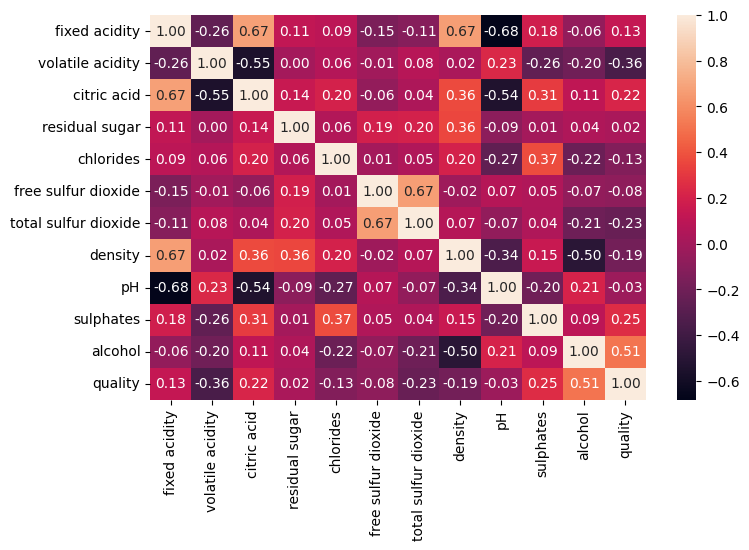

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.show()


In [ ]:
y_data = df['quality']
x_data = df.drop('quality', axis = 1)
print(x_data.shape, y_data.shape)

(1599, 11) (1599,)


In [ ]:

split = StratifiedShuffleSplit(10)
pip = Pipeline([("pre", StandardScaler()),
                ("model", KNeighborsClassifier())
                ])

pam = [
    {"pre":[StandardScaler()],
     "model":[KNeighborsClassifier()],
     "model__n_neighbors" : range(1,80,2)},
    {"pre":[None],
     "model":[GaussianNB()]},
    {"pre":[None],
     "model":[DecisionTreeClassifier()],
     "model__max_depth":range(1,20),
     "model__criterion":['gini', 'entropy']},
    {"pre":[None],
     "model":[RandomForestClassifier()],
     "model__n_estimators":[50,201,50],
     "model__criterion":['gini', 'entropy']}
]

grid_m = GridSearchCV(pip,
                      pam,
                      cv=split,
                      return_train_score=True,
                      verbose=3)

grid_m.fit(x_data, y_data)
print(grid_m.best_params_, grid_m.best_score_)

Fitting 10 folds for each of 85 candidates, totalling 850 fits
[CV 1/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(train=1.000, test=0.719) total time=   0.0s
[CV 2/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(train=1.000, test=0.725) total time=   0.0s
[CV 3/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(train=1.000, test=0.681) total time=   0.0s
[CV 4/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(train=1.000, test=0.725) total time=   0.0s
[CV 5/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(train=1.000, test=0.719) total time=   0.0s
[CV 6/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(train=1.000, test=0.700) total time=   0.0s
[CV 7/10] END model=KNeighborsClassifier(), model__n_neighbors=1, pre=StandardScaler();, score=(t

# 번외)코드 뜯어보기

In [ ]:
# KNN

'''
KNeighborsClassifier(

n_neighbors=5,
*, weights='uniform',
algorithm='auto',
leaf_size=30, p=2,
metric='minkowski',
metric_params=None,
n_jobs=None
)

'''

In [ ]:
# Naive Bayes

'''
GaussianNB(

*,

priors=None,

var_smoothing=1e-09

)
'''

In [ ]:
# Decision Tree

'''
DecisionTreeClassifier(

*,
criterion='gini',
splitter='best',
max_depth=None,
min_samples_split=2,
min_samples_leaf=1,
min_weight_fraction_leaf=0.0,
max_features=None,
random_state=None,
max_leaf_nodes=None,
min_impurity_decrease=0.0,
class_weight=None,
ccp_alpha=0.0,
monotonic_cst=None

)

'''

In [ ]:
# Random Forest

'''
RandomForestClassifier(
n_estimators: int = 100,
*,
criterion: str = "gini",
max_depth: Unknown | None = None,
min_samples_split: int = 2,
min_samples_leaf: int = 1,
min_weight_fraction_leaf: float = 0,
max_features: str = "sqrt",
max_leaf_nodes: Unknown | None = None,
min_impurity_decrease: float = 0,
bootstrap: bool = True,
oob_score: bool = False,
n_jobs: Unknown | None = None,
random_state: Unknown | None = None,
verbose: int = 0,
warm_start: bool = False,
class_weight: Unknown | None = None,
ccp_alpha: float = 0,
max_samples: Unknown | None = None,
monotonic_cst: Unknown | None = None
)
'''